In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

def gerar_dataset_vendas(n_registros=200, seed=42):
    """Gera um dataset sintético de vendas com dados intencionalmente sujos."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse", "Headset"]
    categorias = {
        "Notebook": "Computadores",
        "Smartphone": "Celulares",
        "Tablet": "Celulares",
        "Monitor": "Computadores",
        "Teclado": "Periféricos",
        "Mouse": "Periféricos",
        "Headset": "Periféricos"
    }

    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 51)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):

        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)

        preco_base = {
            "Notebook": 3500,
            "Smartphone": 2200,
            "Tablet": 1800,
            "Monitor": 1200,
            "Teclado": 250,
            "Mouse": 120,
            "Headset": 350
        }[produto]

        preco = round(preco_base * random.uniform(0.85, 1.15), 2)
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None
        if random.random() < 0.04:
            preco = None
        if random.random() < 0.03:
            produto = "  " + produto

        dados.append({
            "id_venda": i + 1,
            "data_venda": data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVÁLIDA",
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

# Gerar e salvar dataset
df_bruto = gerar_dataset_vendas()
df_bruto.to_csv("vendas.csv", index=False)

print(f"Dataset gerado com {len(df_bruto)} registros.")
print(df_bruto.head(5))

Dataset gerado com 200 registros.
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-05-20  Cliente_035       Mouse   Periféricos   Sudeste   
1         2  2024-02-17  Cliente_042     Teclado   Periféricos     Norte   
2         3  2024-05-22  Cliente_022     Monitor  Computadores  Nordeste   
3         4  2024-06-21  Cliente_017  Smartphone     Celulares   Sudeste   
4         5  2024-07-12  Cliente_024       Mouse   Periféricos     Norte   

   quantidade  preco_unitario  
0         2.0          102.90  
1         7.0          214.88  
2         4.0             NaN  
3         4.0         2501.76  
4         8.0          121.30  


In [2]:
df_bruto.shape

(200, 8)

In [3]:
df_bruto.columns

Index(['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao',
       'quantidade', 'preco_unitario'],
      dtype='str')

In [4]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        200 non-null    int64  
 1   data_venda      200 non-null    str    
 2   cliente         200 non-null    str    
 3   produto         200 non-null    str    
 4   categoria       200 non-null    str    
 5   regiao          200 non-null    str    
 6   quantidade      194 non-null    float64
 7   preco_unitario  190 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 12.6 KB


In [5]:
df_bruto.isnull().sum()

id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10
dtype: int64

In [6]:
df_bruto.describe()

,id_venda,quantidade,preco_unitario
count,200.000000,194.000000,190.000000
mean,100.500000,5.427835,1337.999789
std,57.879185,2.792931,1128.654914
min,1.000000,1.000000,102.900000
25%,50.750000,3.000000,264.015000
50%,100.500000,6.000000,1209.295000
75%,150.250000,8.000000,1991.257500
max,200.000000,10.000000,3996.800000


In [7]:
df_bruto.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30


In [8]:
df = df_bruto.copy()

In [9]:
df.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30


In [10]:
def inspecionar_dados(df):
    """Exibe informações básicas do DataFrame."""
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    print(f"\nEstatísticas descritivas:\n{df.describe()}")


In [11]:
inspecionar_dados(df)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (200, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-05-20  Cliente_035       Mouse   Periféricos   Sudeste   
1         2  2024-02-17  Cliente_042     Teclado   Periféricos     Norte   
2         3  2024-05-22  Cliente_022     Monitor  Computadores  Nordeste   
3         4  2024-06-21  Cliente_017  Smartphone     Celular

In [12]:
import re

def limpar_dados(df):
    """
    Limpa e trata o DataFrame de vendas.
    Retorna o DataFrame limpo e um relatório de limpeza.
    """
    n_inicial = len(df)
    relatorio = {}

    # 1. Remover espaços extras em colunas de texto
    colunas_texto = df.select_dtypes(include="object").columns
    for col in colunas_texto:
        df[col] = df[col].str.strip()

    # 2. Converter data e remover datas inválidas
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    n_datas_invalidas = df["data_venda"].isnull().sum()
    df = df.dropna(subset=["data_venda"])
    relatorio["datas_invalidas_removidas"] = n_datas_invalidas

    # 3. Remover linhas com quantidade ou preço nulos
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # 4. Garantir tipos numéricos corretos
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    n_final = len(df)
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = n_final
    relatorio["registros_removidos_total"] = n_inicial - n_final

    print("\n=== RELATÓRIO DE LIMPEZA ===")
    for chave, valor in relatorio.items():
        print(f"  {chave}: {valor}")
        return df, relatorio


In [13]:
limpar_dados(df)


=== RELATÓRIO DE LIMPEZA ===
  datas_invalidas_removidas: 4


C:\Users\PC\AppData\Local\Temp\ipykernel_10396\3459720878.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


(     id_venda data_venda      cliente     produto     categoria        regiao  \
 0           1 2024-05-20  Cliente_035       Mouse   Periféricos       Sudeste   
 1           2 2024-02-17  Cliente_042     Teclado   Periféricos         Norte   
 3           4 2024-06-21  Cliente_017  Smartphone     Celulares       Sudeste   
 4           5 2024-07-12  Cliente_024       Mouse   Periféricos         Norte   
 5           6 2024-04-26  Cliente_025  Smartphone     Celulares      Nordeste   
 ..        ...        ...          ...         ...           ...           ...   
 195       196 2024-07-15  Cliente_021    Notebook  Computadores         Norte   
 196       197 2024-03-22  Cliente_002       Mouse   Periféricos       Sudeste   
 197       198 2024-05-03  Cliente_042     Monitor  Computadores  Centro-Oeste   
 198       199 2024-02-25  Cliente_024      Tablet     Celulares       Sudeste   
 199       200 2024-04-09  Cliente_036     Monitor  Computadores      Nordeste   
 
      quantida

In [14]:
def criar_colunas_derivadas(df):
    """Cria colunas calculadas e derivadas a partir do dataset limpo."""

    # Receita total por linha de venda
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Extração de componentes de data
    df["mes"] = df["data_venda"].dt.month
    df["mes_nome"] = df["data_venda"].dt.strftime("%B")  # nome do mês
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data_venda"].dt.year

    # Classificação da receita por item com numpy.select (transformação condicional vetorizada)
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]
    classificacoes = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, classificacoes, default="Não Classificado")
    print("\n=== COLUNAS DERIVADAS CRIADAS ===")
    print(df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())

    return df




In [15]:
criar_colunas_derivadas(df)


=== COLUNAS DERIVADAS CRIADAS ===
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-05-20         205.80  5.0      Q2.0        Baixo Valor
1 2024-02-17        1504.16  2.0      Q1.0        Médio Valor
2 2024-05-22            NaN  5.0      Q2.0   Não Classificado
3 2024-06-21       10007.04  6.0      Q2.0         Alto Valor
4 2024-07-12         970.40  7.0      Q3.0        Médio Valor


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90,205.80,5.0,May,Q2.0,2024.0,Baixo Valor
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88,1504.16,2.0,February,Q1.0,2024.0,Médio Valor
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN,NaN,5.0,May,Q2.0,2024.0,Não Classificado
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76,10007.04,6.0,June,Q2.0,2024.0,Alto Valor
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30,970.40,7.0,July,Q3.0,2024.0,Médio Valor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,2024-07-15,Cliente_021,Notebook,Computadores,Norte,1.0,3279.72,3279.72,7.0,July,Q3.0,2024.0,Médio Valor
196,197,2024-03-22,Cliente_002,Mouse,Periféricos,Sudeste,6.0,108.83,652.98,3.0,March,Q1.0,2024.0,Médio Valor
197,198,2024-05-03,Cliente_042,Monitor,Computadores,Centro-Oeste,9.0,1184.60,10661.40,5.0,May,Q2.0,2024.0,Alto Valor
198,199,2024-02-25,Cliente_024,Tablet,Celulares,Sudeste,9.0,1534.42,13809.78,2.0,February,Q1.0,2024.0,Alto Valor


In [16]:
def calcular_metricas(df):
    """Calcula e retorna métricas agregadas do dataset."""
    metricas = {}

    # Receita por mês
    por_mes = df.groupby("mes").agg( receita_total=("receita_total", "sum"),
        quantidade=("quantidade", "sum"),
        n_vendas=("id_venda", "count")
    ).reset_index().sort_values("mes")
    metricas["por_mes"] = por_mes

    # Top 5 produtos por receita
    top_produtos = df.groupby("produto")["receita_total"].sum()\
                     .sort_values(ascending=False).head(5).reset_index()
    metricas["top_produtos"] = top_produtos

    # Receita por categoria
    por_categoria = df.groupby("categoria")["receita_total"].sum().reset_index()
    metricas["por_categoria"] = por_categoria

    # Receita por região
    por_regiao = df.groupby("regiao").agg(
        receita_total=("receita_total", "sum"),
        media_ticket=("receita_total", "mean")
    ).reset_index().sort_values("receita_total", ascending=False)
    metricas["por_regiao"] = por_regiao

    # Exibição
    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        print(tabela.to_string(index=False))

    return metricas



In [17]:
calcular_metricas(df)


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
 1.0       47169.34        45.0        10
 2.0       69968.85        94.0        16
 3.0      124532.20        91.0        19
 4.0      103611.52        75.0        15
 5.0      106602.03       100.0        17
 6.0      117334.85        75.0        16
 7.0      110935.66        99.0        19
 8.0      140320.55        81.0        15
 9.0       90627.26        66.0        11
10.0      137350.13       127.0        21
11.0       69554.97        65.0        13
12.0      115925.56       122.0        24

=== TOP PRODUTOS ===
   produto  receita_total
  Notebook      354209.68
    Tablet      353176.81
Smartphone      234977.18
   Monitor      191560.87
   Headset       59314.70

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares      588153.99
Computadores      545770.55
 Periféricos      107676.23

=== POR REGIAO ===
      regiao  receita_total  media_ticket
     Sudeste      333455.14   8336.378500
Centro-Oeste      24

{'por_mes':      mes  receita_total  quantidade  n_vendas
 0    1.0       47169.34        45.0        10
 1    2.0       69968.85        94.0        16
 2    3.0      124532.20        91.0        19
 3    4.0      103611.52        75.0        15
 4    5.0      106602.03       100.0        17
 5    6.0      117334.85        75.0        16
 6    7.0      110935.66        99.0        19
 7    8.0      140320.55        81.0        15
 8    9.0       90627.26        66.0        11
 9   10.0      137350.13       127.0        21
 10  11.0       69554.97        65.0        13
 11  12.0      115925.56       122.0        24,
 'top_produtos':       produto  receita_total
 0    Notebook      354209.68
 1      Tablet      353176.81
 2  Smartphone      234977.18
 3     Monitor      191560.87
 4     Headset       59314.70,
 'por_categoria':       categoria  receita_total
 0     Celulares      588153.99
 1  Computadores      545770.55
 2   Periféricos      107676.23,
 'por_regiao':          regiao  re

In [18]:
def segmentar_clientes(df):
    """Segmenta clientes pelo total gasto usando groupby e lambda."""

    clientes = df.groupby("cliente")["receita_total"].sum().reset_index()
    clientes.columns = ["cliente", "total_gasto"]

    # Classificação usando função lambda com condicionais
    clientes["segmento"] = clientes["total_gasto"].apply(
        lambda gasto: "Ouro" if gasto > 15000
                      else ("Prata" if gasto >= 5000 else "Bronze")
    )

    clientes = clientes.sort_values("total_gasto", ascending=False)

    print("\n=== SEGMENTAÇÃO DE CLIENTES ===")
    print(clientes.head(10).to_string(index=False))
    print(f"\nDistribuição de segmentos:\n{clientes['segmento'].value_counts()}")

    return clientes


In [19]:
segmentar_clientes(df)


=== SEGMENTAÇÃO DE CLIENTES ===
    cliente  total_gasto segmento
Cliente_015     82964.76     Ouro
Cliente_035     75402.52     Ouro
Cliente_048     62293.77     Ouro
Cliente_024     57381.21     Ouro
Cliente_006     50249.74     Ouro
Cliente_004     50106.56     Ouro
Cliente_032     45532.00     Ouro
Cliente_044     43513.88     Ouro
Cliente_016     42754.07     Ouro
Cliente_017     41983.05     Ouro

Distribuição de segmentos:
segmento
Ouro      31
Prata     10
Bronze     8
Name: count, dtype: int64


,cliente,total_gasto,segmento
13,Cliente_015,82964.76,Ouro
33,Cliente_035,75402.52,Ouro
46,Cliente_048,62293.77,Ouro
22,Cliente_024,57381.21,Ouro
5,Cliente_006,50249.74,Ouro
3,Cliente_004,50106.56,Ouro
30,Cliente_032,45532.00,Ouro
42,Cliente_044,43513.88,Ouro
14,Cliente_016,42754.07,Ouro
15,Cliente_017,41983.05,Ouro


In [20]:
def calcular_estatisticas_numpy(df):
    """Usa NumPy para calcular estatísticas sobre as receitas."""
    print("\n=== ESTATÍSTICAS COM NUMPY ===")

    receitas = df["receita_total"].dropna().to_numpy()  # Converte para array NumPy

    media = np.mean(receitas)
    mediana = np.median(receitas)
    desvio_padrao = np.std(receitas)
    total = np.sum(receitas)
    p25 = np.percentile(receitas, 25)
    p75 = np.percentile(receitas, 75)

    print(f"  Receita média por venda:    R$ {media:.2f}")
    print(f"  Receita mediana por venda:  R$ {mediana:.2f}")
    print(f"  Desvio padrão:              R$ {desvio_padrao:.2f}")
    print(f"  Receita total:              R$ {total:.2f}")
    print(f"  Percentil 25 (Q1):          R$ {p25:.2f}")
    print(f"  Percentil 75 (Q3):          R$ {p75:.2f}")

    # Broadcasting: normalizar receitas entre 0 e 1
    receitas_normalizadas = (receitas - receitas.min()) / (receitas.max() - receitas.min())
    print(f"\n  Receitas normalizadas (primeiros 5): {receitas_normalizadas[:5].round(4)}")

    # Operação vetorizada: identificar vendas acima da média sem loop
    acima_da_media = receitas[receitas > media]
    print(f"\n  Vendas acima da média: {len(acima_da_media)} de {len(receitas)}")

    return {
        "media": media, "mediana": mediana,
        "desvio_padrao": desvio_padrao, "total": total
    }



In [21]:
calcular_estatisticas_numpy(df)


=== ESTATÍSTICAS COM NUMPY ===
  Receita média por venda:    R$ 6747.83
  Receita mediana por venda:  R$ 3841.00
  Desvio padrão:              R$ 6642.87
  Receita total:              R$ 1241600.77
  Percentil 25 (Q1):          R$ 1215.35
  Percentil 75 (Q3):          R$ 10878.61

  Receitas normalizadas (primeiros 5): [0.     0.042  0.3168 0.0247 0.1162]

  Vendas acima da média: 74 de 184


{'media': np.float64(6747.830271739131),
 'mediana': np.float64(3841.0),
 'desvio_padrao': np.float64(6642.869611190948),
 'total': np.float64(1241600.77)}

In [72]:
por_mes = df.groupby("mes", as_index=False)["receita_total"].sum()

top_produtos = (
    df.groupby("produto", as_index=False)["receita_total"]
    .sum()
    .sort_values("receita_total", ascending=False)
    .head(5)
)

metricas = {
    "por_mes": por_mes,
    "top_produtos": top_produtos
}



In [73]:

import matplotlib.pyplot as plt
import seaborn as sns
import os

def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """Gera e exporta visualizações dos dados de vendas."""
    os.makedirs(output_dir, exist_ok=True)
    

    # Configurações visuais globais
    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams["figure.figsize"] = (12, 6)
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12

    # --- Gráfico 1: Receita por Mês (linha) ---
    fig, ax = plt.subplots()
    por_mes = metricas["por_mes"]
    ax.plot(por_mes["mes"], por_mes["receita_total"], marker="o", linewidth=2, color="#2196F3")
    ax.fill_between(por_mes["mes"], por_mes["receita_total"], alpha=0.15, color="#2196F3")
    ax.set_title("Receita Total por Mês (2024)")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita Total (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun",
                         "Jul","Ago","Set","Out","Nov","Dez"], rotation=45)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "vendas_por_mes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}")

    # --- Gráfico 2: Top 5 Produtos (barras horizontais) ---
    fig, ax = plt.subplots()
    top = metricas["top_produtos"]
    sns.barplot(data=top, y="produto", x="receita_total", ax=ax, palette="Blues_d")
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    for container in ax.containers:
        ax.bar_label(container, fmt="R$ %.0f", padding=5)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "top_produtos.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}")

    # --- Gráfico 3: Distribuição de Receita por Região (boxplot) ---
    fig, ax = plt.subplots()
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, palette="Set2")
    ax.set_title("Distribuição de Receita por Transação – Por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "distribuicao_regioes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}")

    print("\n=== VISUALIZAÇÕES GERADAS COM SUCESSO ===")


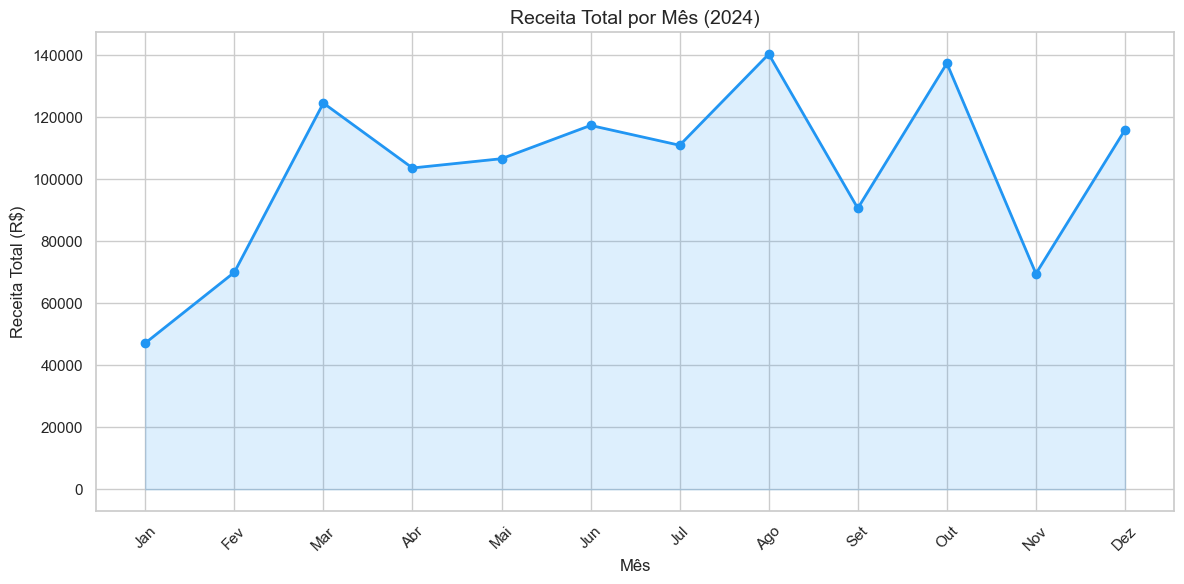

  Gráfico exportado: outputs/graficos\vendas_por_mes.png


C:\Users\PC\AppData\Local\Temp\ipykernel_10396\1414169439.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y="produto", x="receita_total", ax=ax, palette="Blues_d")


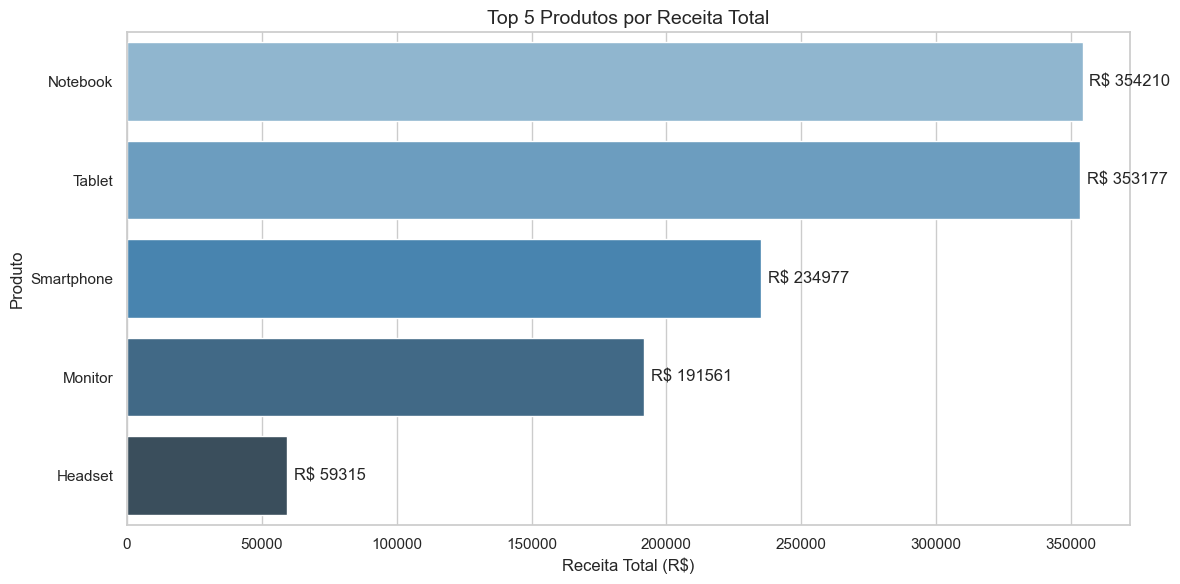

  Gráfico exportado: outputs/graficos\top_produtos.png


C:\Users\PC\AppData\Local\Temp\ipykernel_10396\1414169439.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, palette="Set2")


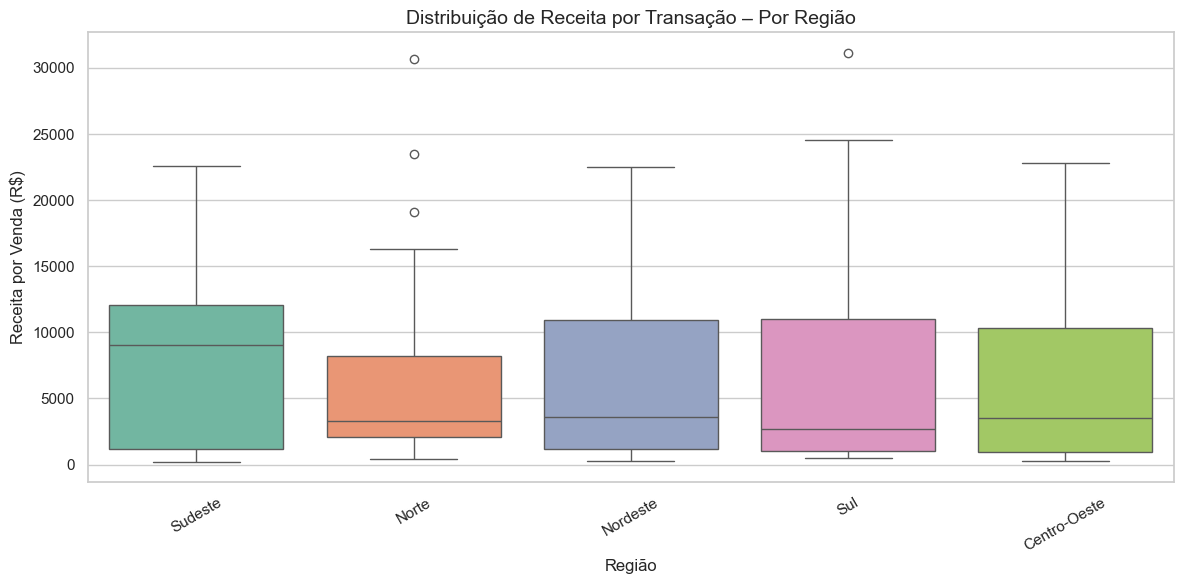

  Gráfico exportado: outputs/graficos\distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS COM SUCESSO ===


In [74]:
gerar_visualizacoes(df, metricas)